# Zadanie 5
1. Načítajte z knižnice keras dátovú množinu reuters, ktorá obsahuje texty novinových správ klasifikovaných do 46 kategórií.
2. Vhodne predspracujte dáta. Použite vektorovú reprezentáciu slov o veľkosti 128.
3. Navrhnite a naučte vhodnú architektúru s LSTM vrstvami. Pri učení zobrazte priebeh presnosti na trénovacích a testovacích dátach.
4. Otestujte výslednú naučenú sieť na testovacej množine a vypočítajte výslednú presnosť.

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 48.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 91.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(12345)

from tensorflow.keras.datasets import reuters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.layers import Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

In [10]:
num_words = 5000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=num_words)
print(x_train.shape, x_test.shape)

(8982,) (2246,)


In [11]:
print(x_train[0])

[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [14]:
max_review_length = 500
x_train = sequence.pad_sequences(x_train, maxlen=max_review_length) 
x_test = sequence.pad_sequences(x_test, maxlen=max_review_length)  

print(x_train[0])      
print(len(x_train[0])) 

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [21]:
x_train.shape

(8982, 500)

In [22]:
embedding_length = 128 # matica 500x128

model = Sequential() 
model.add(Embedding(num_words, embedding_length, input_length=max_review_length))
model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(46, activation='softmax'))

In [23]:
adam = Adam()
model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

In [28]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [29]:
f = model.fit(x_train, y_train, epochs=15, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1500s 11s/step - accuracy: 0.5630 - loss: 1.7333 - val_accuracy: 0.5592 - val_loss: 1.7168
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1500s 11s/step - accuracy: 0.5829 - loss: 1.6658 - val_accuracy: 0.5984 - val_loss: 1.6625
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1597s 11s/step - accuracy: 0.5979 - loss: 1.6420 - val_accuracy: 0.5761 - val_loss: 1.6668
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1669s 12s/step - accuracy: 0.6239 - loss: 1.5356 - val_accuracy: 0.6193 - val_loss: 1.5291
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1673s 12s/step - accuracy: 0.6385 - loss: 1.4697 - val_accuracy: 0.6180 - val_loss: 1.5010
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1669s 12s/step - accuracy: 0.6372 - loss: 1.4587 - val_accuracy: 0.5877 - val_loss: 1.5908
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1678s 12s/step - accuracy: 0.6470 - loss: 1.3855 - val_accuracy: 0.6305 - val_loss: 1.4492
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1668s 12s/step - accuracy: 0.6816 - loss: 1

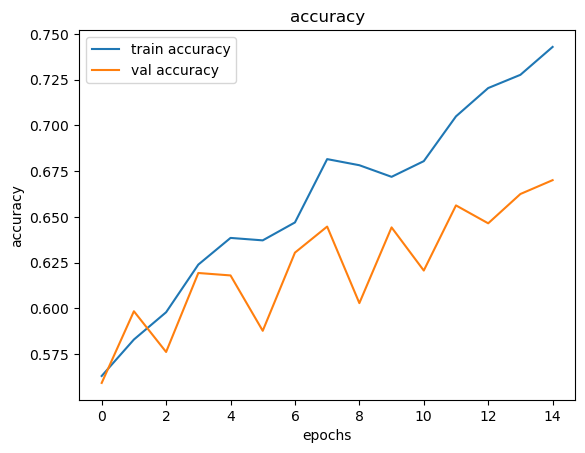

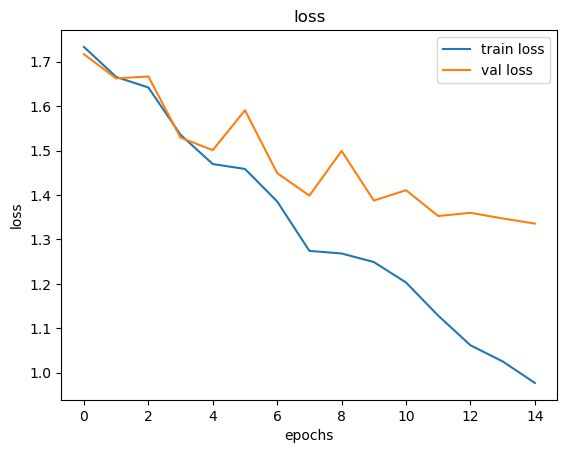

In [30]:
import matplotlib.pyplot as plt

plt.plot(f.history['accuracy'], label='train accuracy')
plt.plot(f.history['val_accuracy'], label='val accuracy')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.plot(f.history['loss'], label='train loss')
plt.plot(f.history['val_loss'], label='val loss')
plt.title('loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


In [35]:
embedding_length = 128 # matica 500x128

model = Sequential() 
model.add(Embedding(num_words, embedding_length, input_length=max_review_length))
model.add(Bidirectional(LSTM(128, dropout=0.3)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(46, activation='softmax'))

In [36]:
adam = Adam()
model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

In [37]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
f = model.fit(x_train, y_train, epochs=15, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/15
  7/141 ━━━━━━━━━━━━━━━━━━━━ 19:39 9s/step - accuracy: 0.2625 - loss: 3.7566